### Imports

In [1]:
import time
from collections import defaultdict
from typing import Any, Callable, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pmdarima as pm
import scipy.stats as sps
import seaborn as sns
import statsmodels
import statsmodels.api as sm
import sys
import torch
import tsfresh
from catboost import CatBoostRegressor
from IPython.display import HTML, clear_output, display
from prophet import Prophet
from pylab import rcParams
from sktime.split import ExpandingWindowSplitter
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsforecast import models as sf_models
from statsforecast.models import (
    SimpleExponentialSmoothing,
    SimpleExponentialSmoothingOptimized,
)
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm
from tqdm.auto import tqdm as auto_tqdm
from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import settings
from tsfresh.utilities.dataframe_functions import impute, roll_time_series

# Visualization setup
sns.set(font_scale=1.3, palette="Set2")
rcParams['figure.figsize'] = 15, 7
%matplotlib inline

In [2]:
sys.path.append('/home/danilach/mipt-stats/SberTs')

%load_ext autoreload
%autoreload 2

from utils.models import DummyConditionalModel, VARModel
from utils.vis import plot_error_matrix, plot_model_pred, calc_average_error
from utils.interface import cross_validate_model, calc_avg_error, build_error_matrix, build_short_error_matrix

In [3]:
df = pd.read_csv("/home/danilach/mipt-stats/SberTs/Data/apk_nona.csv", index_col=0)
df.index = pd.to_datetime(df.index)
cols = df.columns
df.head()       

,USDRUB,Кукуруза,Молоко сырое,Мясо птицы бройлеров в живом весе,Мясо крупного рогатого скота в живом весе,Подсолнечник,Пшеница 1-го класса,Пшеница 3-го класса,Пшеница 5-го класса,Сахар (средняя цена по России),...,"Минтай б/г, Владивосток руб./кг","Минтай б/г, Китай C&F $/т","Сельдь н/р, Владивосток руб./кг","Огурцы тепличные, руб./кг","Томаты тепличные, руб./кг",Колбасы вареные,"Рапс, руб./т","Рапсовое масло EU, $/т","Мука пшеничная, руб./т","Пшеница 12,5% FOB Ново, $/т"
2014-01-01,33.7787,5.10830,19.22489,53.78150,71.50234,9.35469,6.28054,6.64389,6.30182,20.62782,...,50.606061,1370.0,27.272727,109.69276,88.39199,180.11884,10.92124,959.902109,11.66556,281.67
2014-02-01,35.3147,5.52927,20.10432,53.73414,70.26937,8.94873,6.70380,6.83535,6.17293,21.04715,...,46.969697,1400.0,26.590909,133.35480,95.80819,185.95226,11.77707,1025.767008,11.59769,278.50
2014-03-01,36.1269,5.55814,20.39963,54.36590,70.87358,10.37450,7.57283,7.18896,6.00571,22.35493,...,53.939394,1390.0,27.272727,103.82040,85.61886,189.09688,13.14795,1008.712498,11.78734,290.75
2014-04-01,35.6723,6.12138,20.49657,55.41361,71.26701,10.97702,8.14327,7.54990,6.58360,24.33316,...,48.000000,1425.0,28.181818,86.43050,109.40309,191.13037,12.71399,1016.669062,12.26536,291.00
2014-05-01,34.8429,6.69644,20.06417,58.83824,73.39434,11.59955,10.16825,8.12811,7.10044,25.66925,...,47.727273,1440.0,23.863636,61.65754,82.03765,196.68823,11.03515,957.679643,12.84780,269.75


In [4]:
horizon_list = [12, 24, 36, 48]

## Naive Model

In [103]:
matrix_params = {
    "model_class": DummyConditionalModel,
    "df": df,
    "horizon": 12,
    "stride": 1,
    "start_window": 60,
    "model_params": {},
}

In [104]:
naive_model_matrices = {}

for horizon in tqdm(horizon_list):
    matrix_params["horizon"] = horizon
    naive_model_matrices[horizon] = build_error_matrix(**matrix_params)

100%|██████████| 4/4 [00:15<00:00,  3.93s/it]


### Посмотрим на получвшиеся матрицы ошибок

  0%|          | 0/4 [00:00<?, ?it/s]

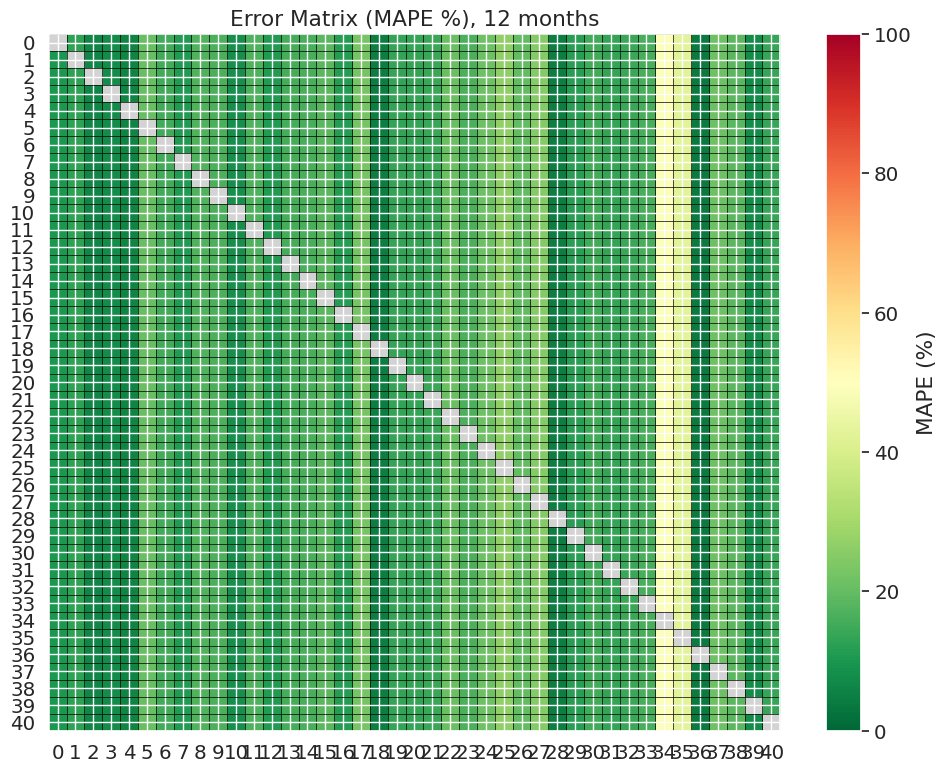

 25%|██▌       | 1/4 [00:00<00:01,  2.22it/s]

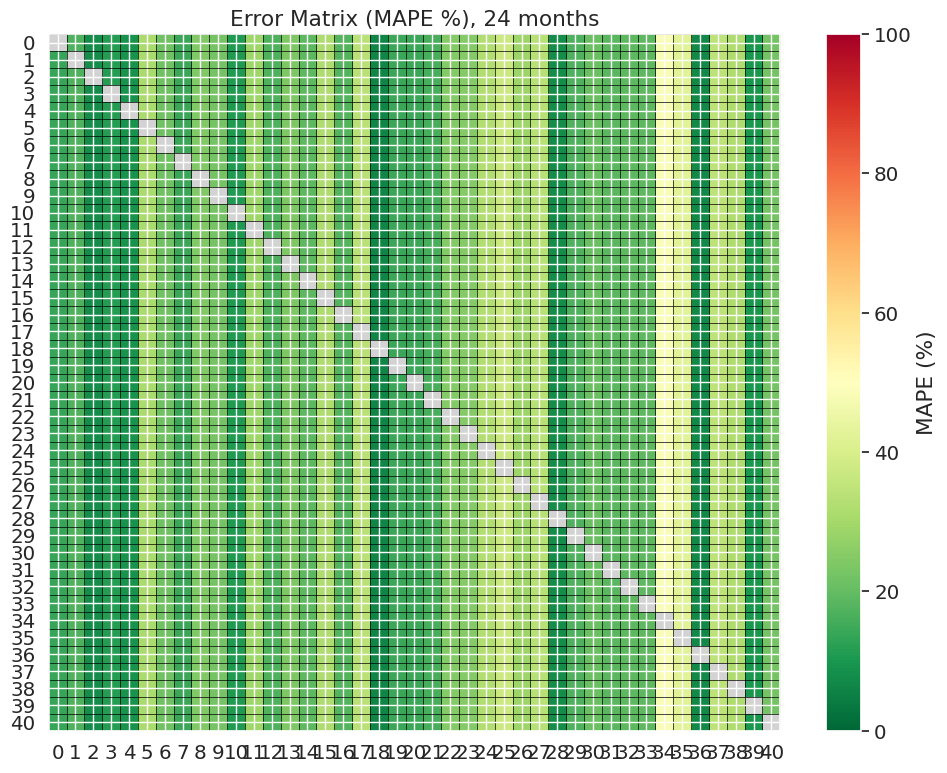

 50%|█████     | 2/4 [00:01<00:01,  1.81it/s]

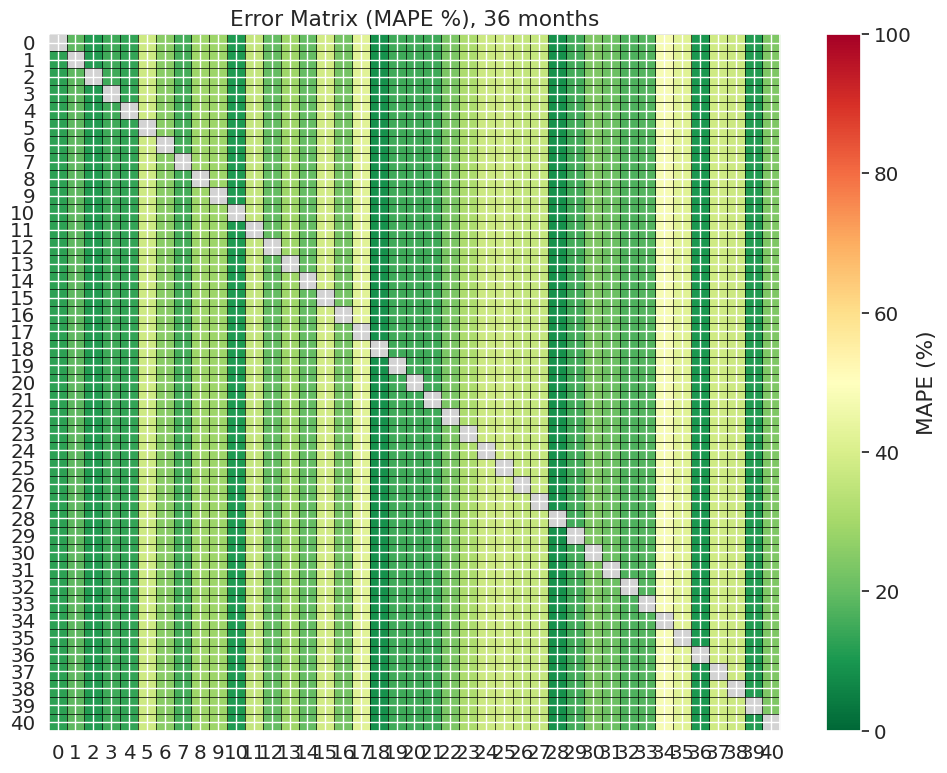

 75%|███████▌  | 3/4 [00:01<00:00,  1.94it/s]

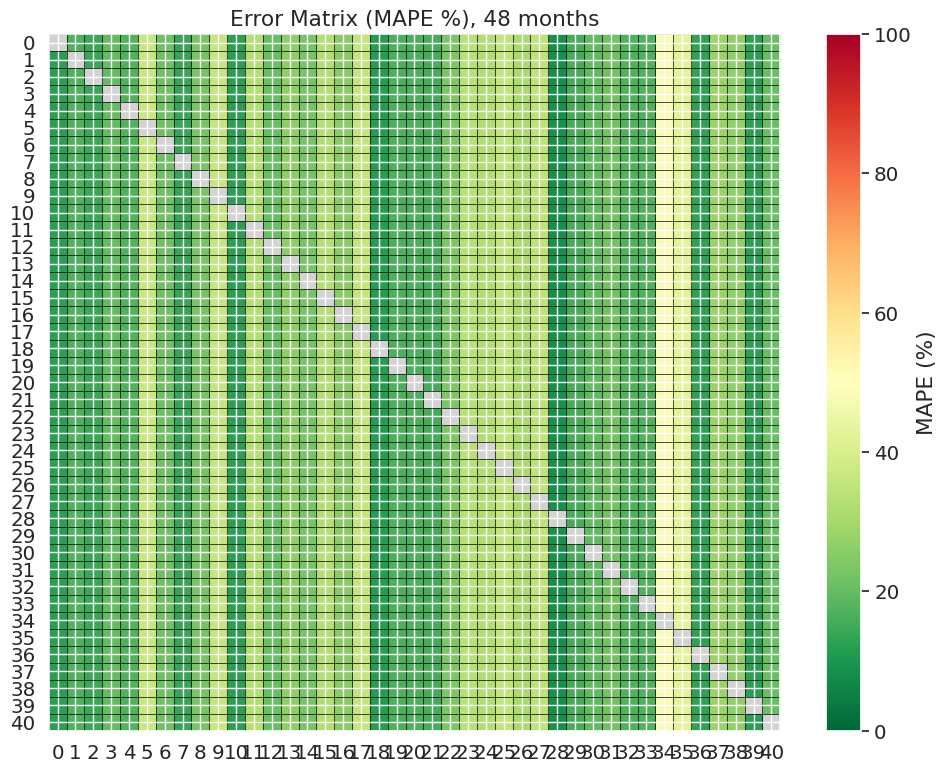

100%|██████████| 4/4 [00:01<00:00,  2.01it/s]


In [18]:
for horizon in tqdm(horizon_list):
    plot_error_matrix(naive_model_matrices[horizon], title=f"Error Matrix (MAPE %), {horizon} months")

### Посмотрим на усреднённый по всем показателям MAPE

In [29]:
for horizon in horizon_list:
    print(f"{horizon} months:    ", end="")
    calc_average_error(naive_model_matrices[horizon])

12 months:    15.99%
24 months:    21.69%
36 months:    24.36%
48 months:    23.48%


Посмотрим также на динамику изменения такого усреднения по мере роста горизонта

In [46]:
avg_mape_list = []

for horizon in tqdm(range(2, 48, 2)):
    matrix_params["horizon"] = horizon
    avg_mape_list.append(np.mean(build_error_matrix(**matrix_params)))

100%|██████████| 23/23 [01:38<00:00,  4.27s/it]


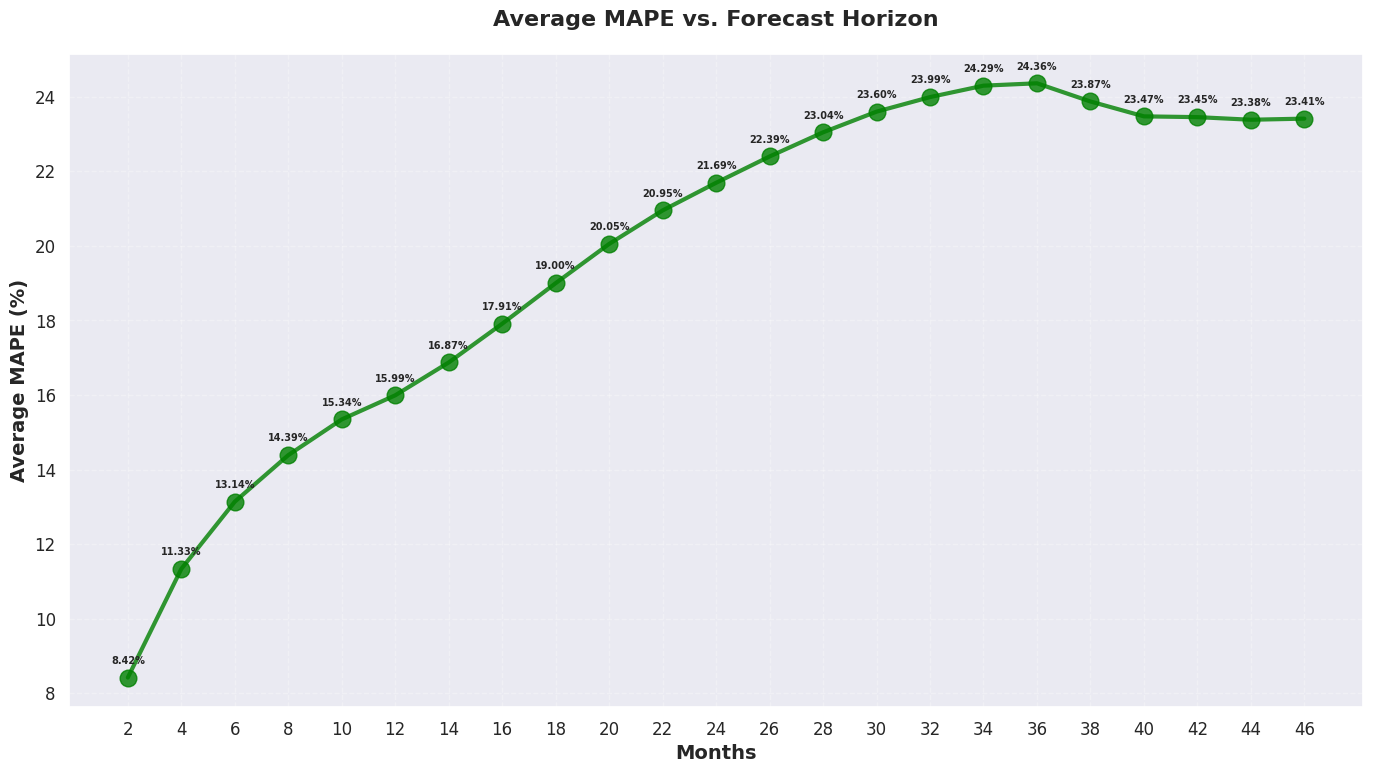

In [ ]:
plt.figure(figsize=(14, 8))
plt.plot(
    np.arange(2, 48, 2),
    avg_mape_list,
    marker="o",
    markersize=12,
    color="g",
    linewidth=3,
    linestyle="-",
    alpha=0.8,
)
plt.title("Average MAPE vs. Forecast Horizon", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Months", fontsize=14, fontweight="bold")
plt.ylabel("Average MAPE (%)", fontsize=14, fontweight="bold")

plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(np.arange(2, 48, 2), fontsize=12)
plt.yticks(fontsize=12)

for i, (x, y) in enumerate(zip(np.arange(2, 48, 2), avg_mape_list)):
    plt.annotate(
        f"{y:.2f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=7,
        fontweight="bold",
    )


plt.tight_layout()
plt.show()

Посмотрим на траектории средних для каждого показателя

In [61]:
mape_matrix = []

for horizon in tqdm(range(2, 48, 4)):
    matrix_params["horizon"] = horizon
    error_matrix = build_error_matrix(**matrix_params)
    # Calculate mean for each column (axis=0)
    mape_matrix.append(np.mean(error_matrix, axis=0))

mape_matrix = np.array(mape_matrix)


100%|██████████| 12/12 [00:51<00:00,  4.26s/it]


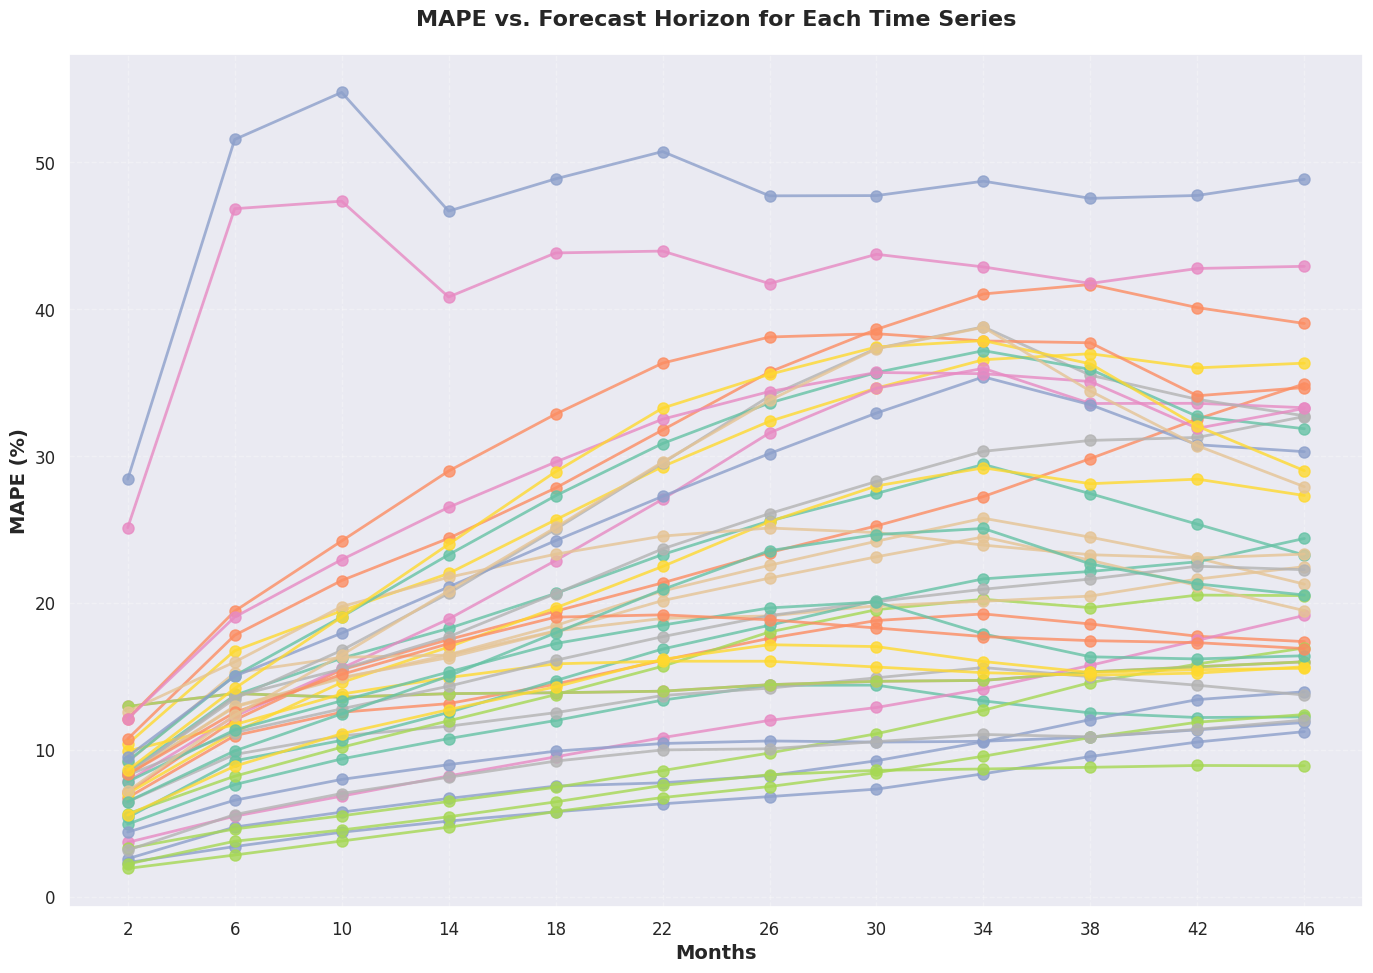

In [64]:
plt.figure(figsize=(14, 10))

for col_idx in range(mape_matrix.shape[1]):
    plt.plot(
        np.arange(2, 48, 4),
        mape_matrix[:, col_idx],
        marker="o",
        markersize=8,
        linewidth=2,
        linestyle="-",
        alpha=0.8,
        label=f"Series {col_idx + 1}",
    )

plt.title(
    "MAPE vs. Forecast Horizon for Each Time Series",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Months", fontsize=14, fontweight="bold")
plt.ylabel("MAPE (%)", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(np.arange(2, 48, 4), fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

## SARIMA

sarima долго обучается (4 часа поэтому только на 12 месяцев есть матрица)

In [121]:
sarima_err_mat_12 = pd.read_csv("/home/danilach/mipt-stats/SberTs/results/sarima_err_mat.csv")

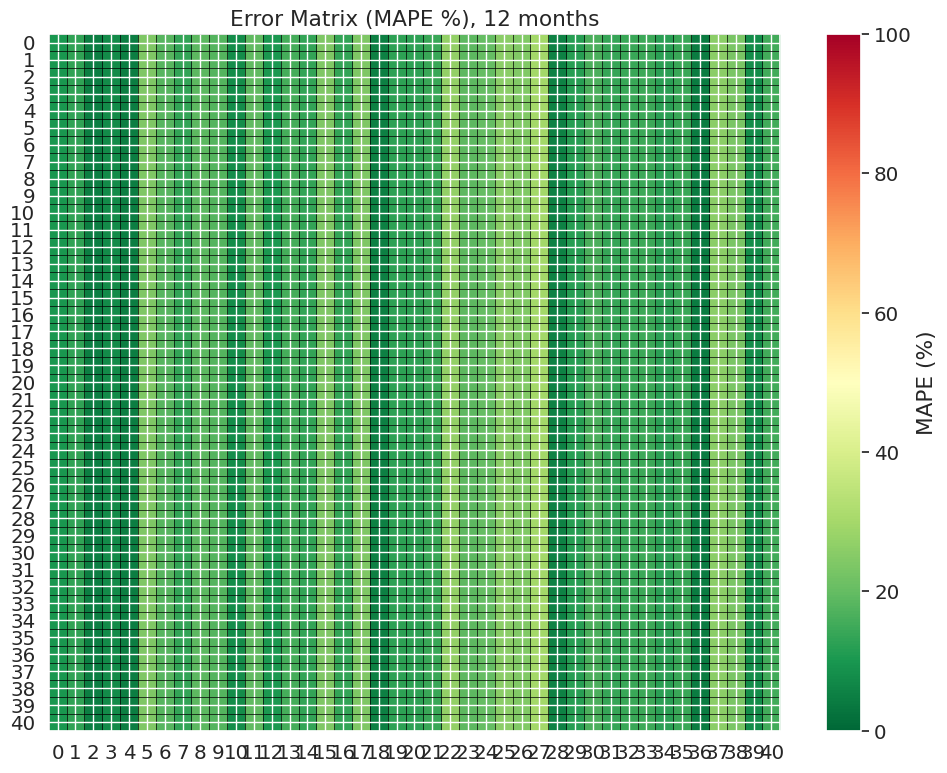

In [67]:
plot_error_matrix(sarima_err_mat_12, title=f"Error Matrix (MAPE %), {12} months")

In [68]:
calc_average_error(sarima_err_mat_12)

15.47%


## Prophet

In [1]:
%load_ext autoreload
%autoreload 2

from utils.models import ProphetModel

In [ ]:
matrix_params = {
    "model_class": ProphetModel,
    "df": df,
    "horizon": 12,
    "stride": 4,
    "start_window": 60,
    "model_params": {},
}

In [73]:
prophet_model_matrices = {}

for horizon in tqdm(horizon_list):
    matrix_params["horizon"] = horizon
    prophet_model_matrices[horizon] = build_short_error_matrix(**matrix_params)

  0%|          | 0/4 [00:00<?, ?it/s]23:57:16 - cmdstanpy - INFO - Chain [1] start processing
23:57:16 - cmdstanpy - INFO - Chain [1] done processing
23:57:16 - cmdstanpy - INFO - Chain [1] start processing
23:57:17 - cmdstanpy - INFO - Chain [1] done processing
23:57:17 - cmdstanpy - INFO - Chain [1] start processing
23:57:17 - cmdstanpy - INFO - Chain [1] done processing
23:57:17 - cmdstanpy - INFO - Chain [1] start processing
23:57:17 - cmdstanpy - INFO - Chain [1] done processing
23:57:17 - cmdstanpy - INFO - Chain [1] start processing
23:57:17 - cmdstanpy - INFO - Chain [1] done processing
23:57:17 - cmdstanpy - INFO - Chain [1] start processing
23:57:17 - cmdstanpy - INFO - Chain [1] done processing
23:57:17 - cmdstanpy - INFO - Chain [1] start processing
23:57:18 - cmdstanpy - INFO - Chain [1] done processing
23:57:18 - cmdstanpy - INFO - Chain [1] start processing
23:57:18 - cmdstanpy - INFO - Chain [1] done processing
23:57:18 - cmdstanpy - INFO - Chain [1] start processing
23

### Посмотрим на получвшиеся матрицы ошибок

  0%|          | 0/4 [00:00<?, ?it/s]

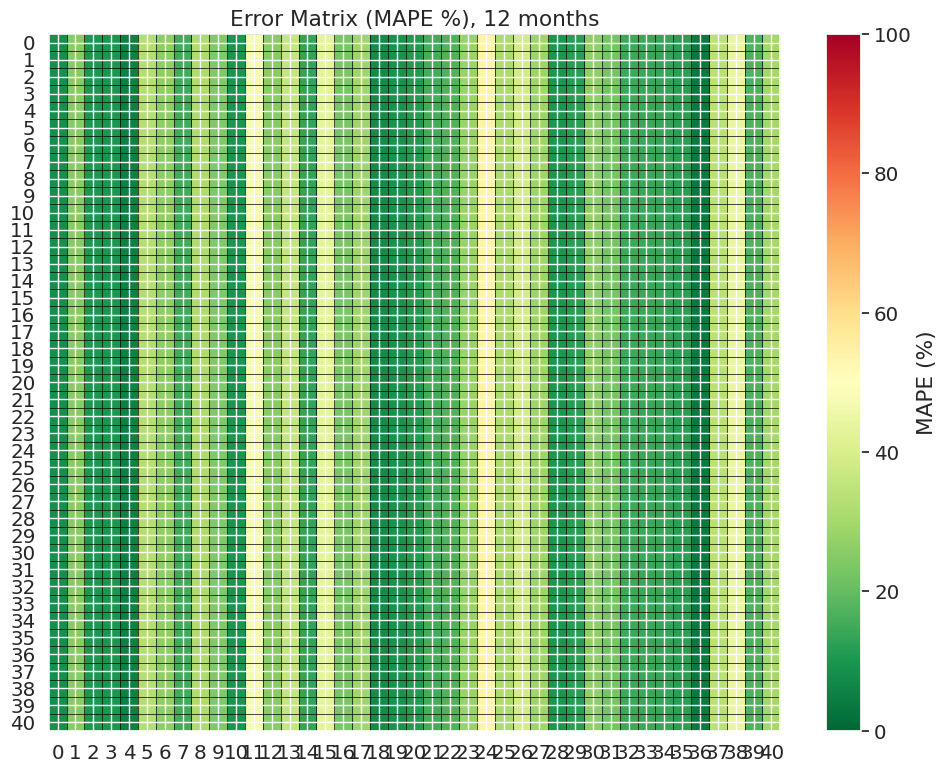

 25%|██▌       | 1/4 [00:00<00:01,  2.24it/s]

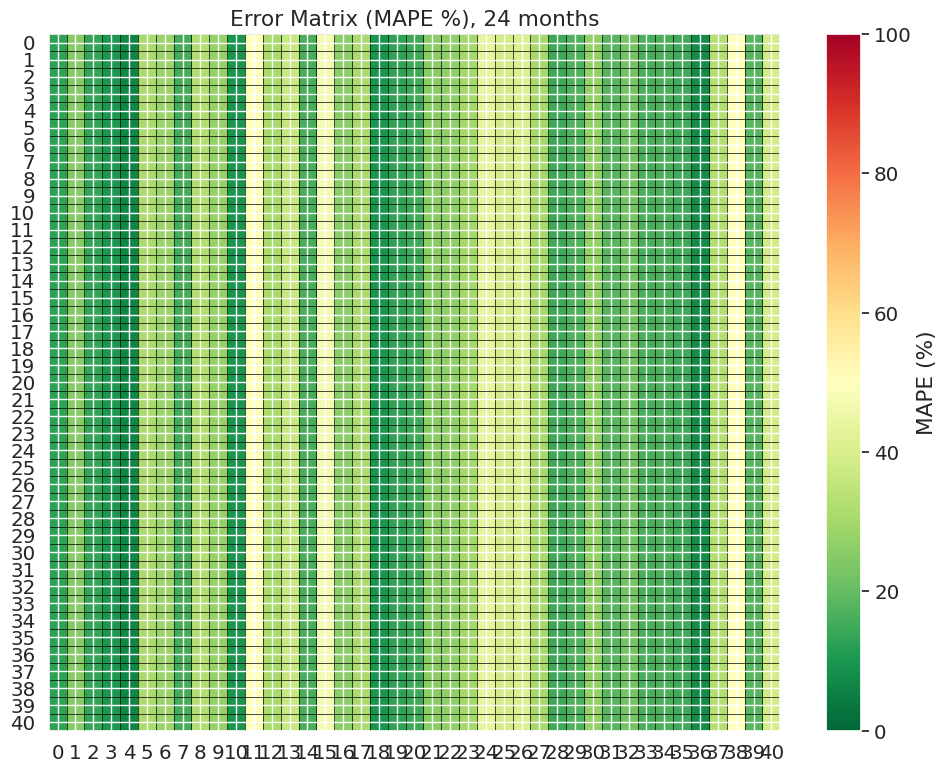

 50%|█████     | 2/4 [00:00<00:00,  2.26it/s]

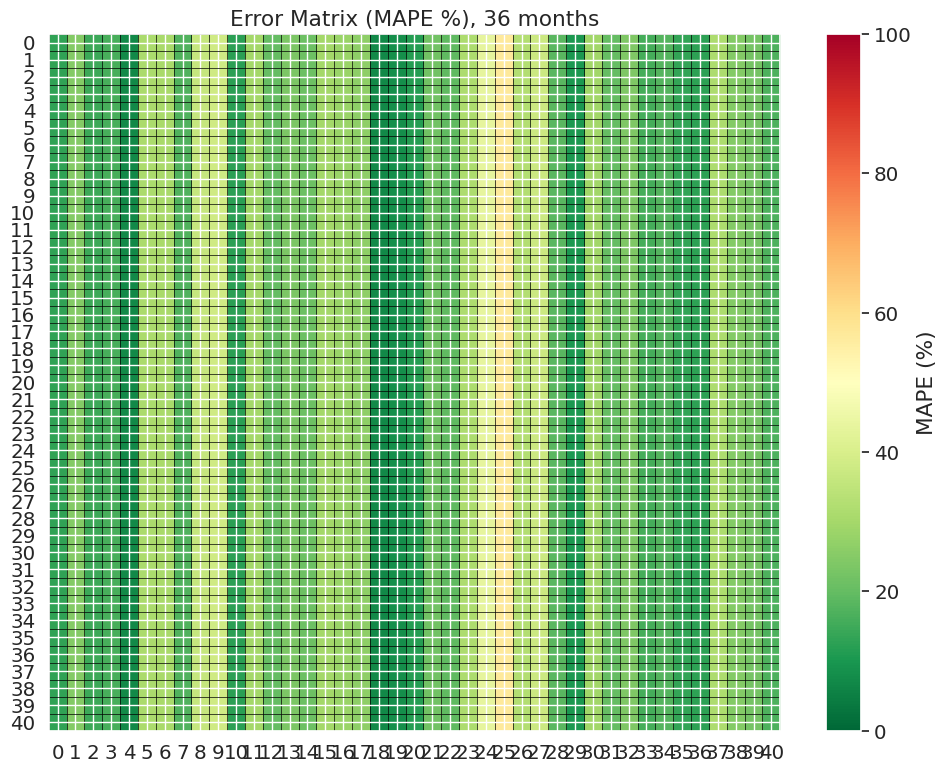

 75%|███████▌  | 3/4 [00:01<00:00,  2.27it/s]

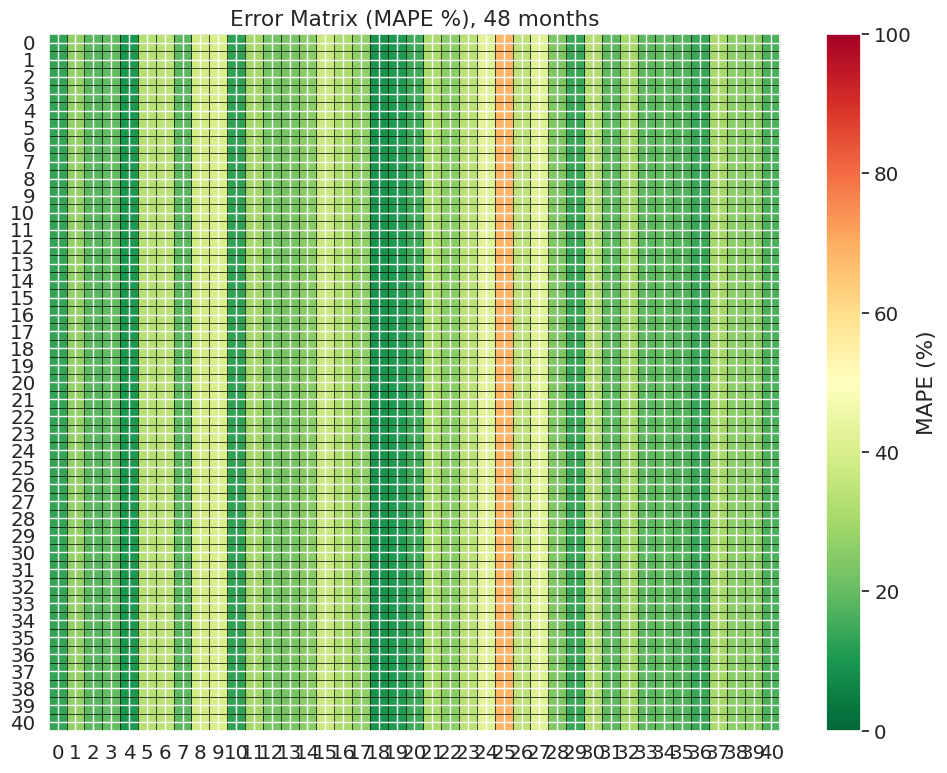

100%|██████████| 4/4 [00:01<00:00,  2.27it/s]


In [75]:
for horizon in tqdm(horizon_list):
    plot_error_matrix(prophet_model_matrices[horizon], title=f"Error Matrix (MAPE %), {horizon} months")

### Посмотрим на усреднённый по всем показателям MAPE

In [77]:
for horizon in horizon_list:
    print(f"{horizon} months:    ", end="")
    calc_average_error(prophet_model_matrices[horizon])


12 months:    22.37%
24 months:    24.81%
36 months:    23.15%
48 months:    25.91%


## Linear Extrapolator

In [7]:
%load_ext autoreload
%autoreload 2

from utils.models import LinearExtrapolator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
matrix_params = {
    "model_class": LinearExtrapolator,
    "df": df,
    "horizon": 12,
    "stride": 1,
    "start_window": 60,
    "model_params": {},
}

In [9]:
extr_model_matrices = {}

for horizon in tqdm(horizon_list):
    matrix_params["horizon"] = horizon
    extr_model_matrices[horizon] = build_error_matrix(**matrix_params)

100%|██████████| 4/4 [00:00<00:00,  5.14it/s]


### Посмотрим на получвшиеся матрицы ошибок


  0%|          | 0/4 [00:00<?, ?it/s]

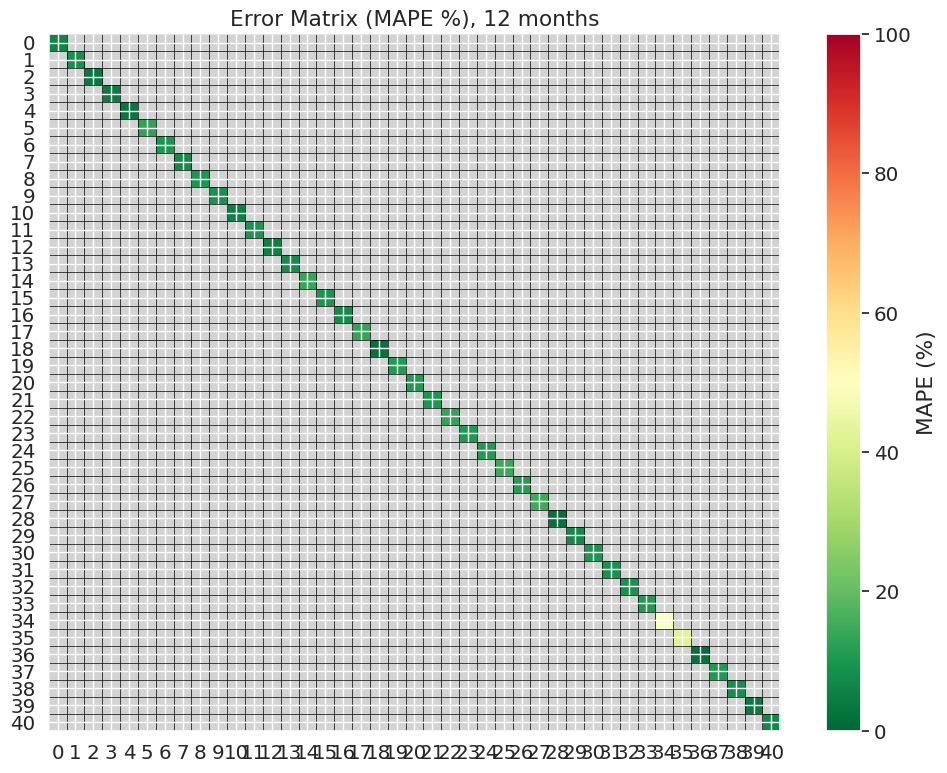

 25%|██▌       | 1/4 [00:00<00:01,  2.28it/s]

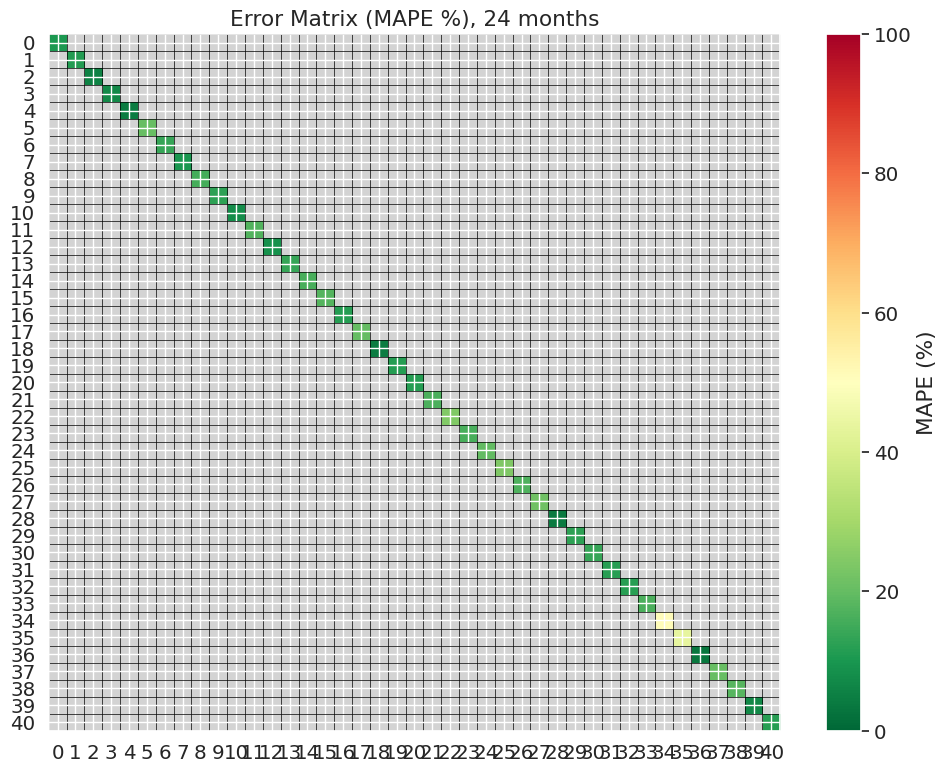

 50%|█████     | 2/4 [00:00<00:00,  2.29it/s]

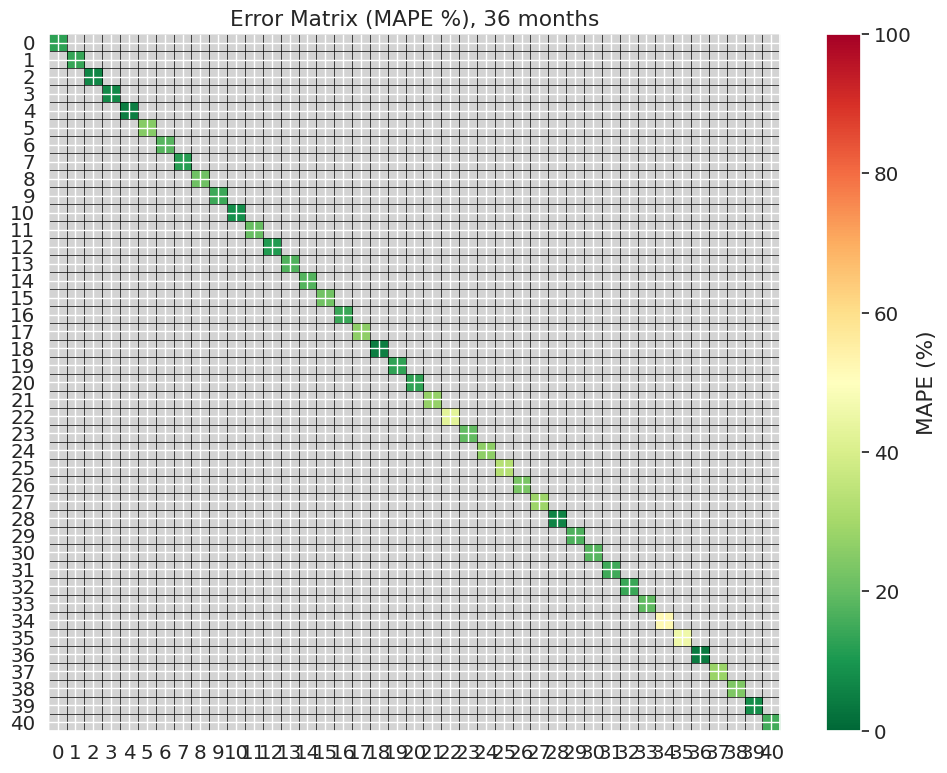

 75%|███████▌  | 3/4 [00:01<00:00,  1.77it/s]

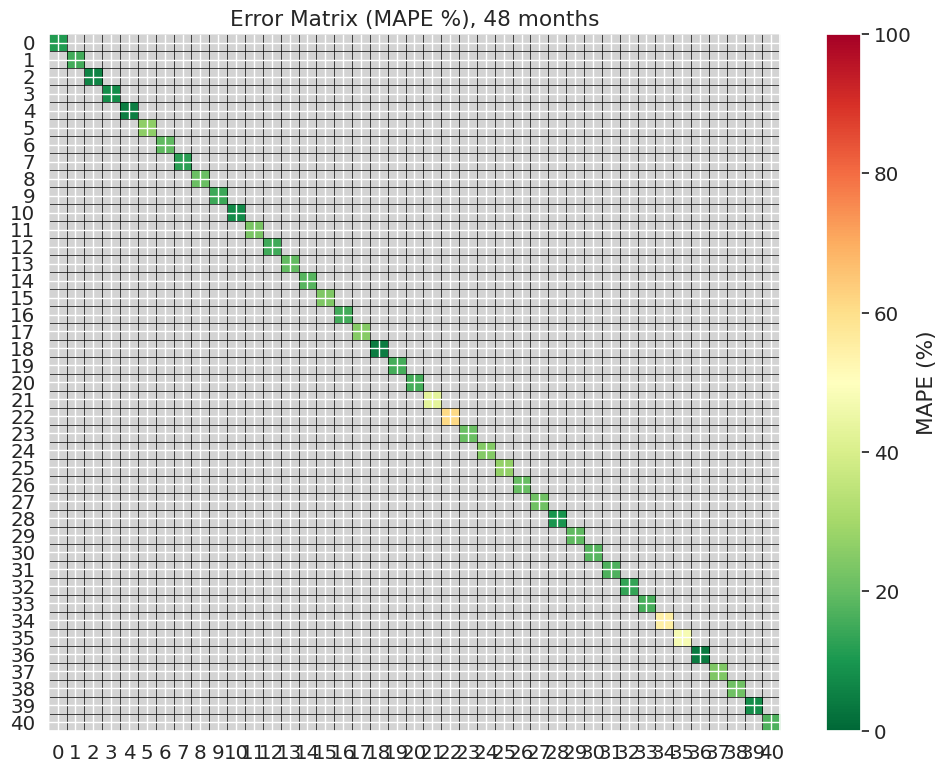

100%|██████████| 4/4 [00:02<00:00,  1.96it/s]


In [84]:
for horizon in tqdm(horizon_list):
    plot_error_matrix(extr_model_matrices[horizon], title=f"Error Matrix (MAPE %), {horizon} months")

### Посмотрим на усреднённый по всем показателям MAPE

In [10]:
for horizon in horizon_list:
    print(f"{horizon} months:    ", end="")
    calc_average_error(extr_model_matrices[horizon])

12 months:    10.64%
24 months:    15.10%
36 months:    18.90%
48 months:    19.86%


In [11]:
avg_mape_list = []

for horizon in tqdm(range(2, 48, 2)):
    matrix_params["horizon"] = horizon
    error_matrix = build_error_matrix(**matrix_params)
    # Calculate mean for each column (axis=0)
    avg_mape_list.append(np.mean(error_matrix))

100%|██████████| 23/23 [00:05<00:00,  4.53it/s]


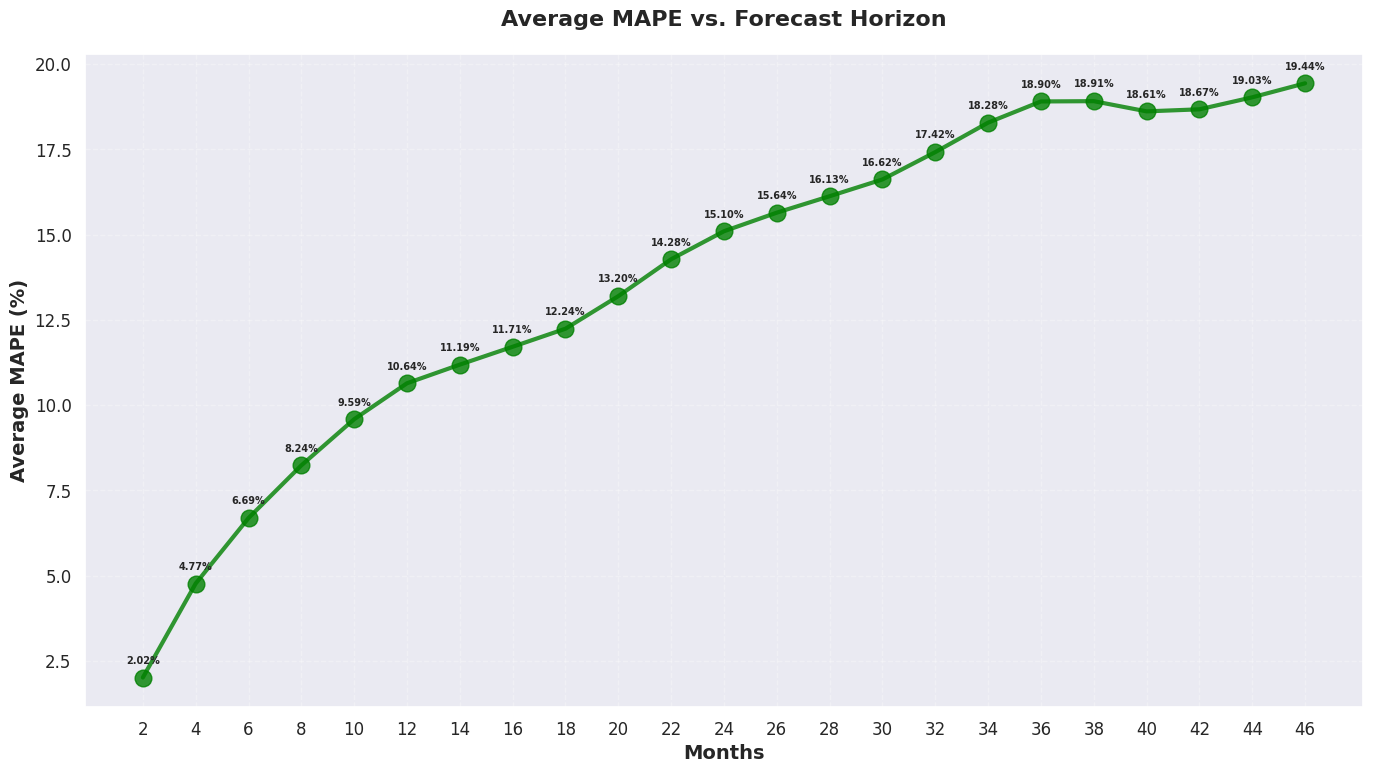

In [12]:
plt.figure(figsize=(14, 8))
plt.plot(
    np.arange(2, 48, 2),
    avg_mape_list,
    marker="o",
    markersize=12,
    color="g",
    linewidth=3,
    linestyle="-",
    alpha=0.8,
)
plt.title("Average MAPE vs. Forecast Horizon", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Months", fontsize=14, fontweight="bold")
plt.ylabel("Average MAPE (%)", fontsize=14, fontweight="bold")

plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(np.arange(2, 48, 2), fontsize=12)
plt.yticks(fontsize=12)

for i, (x, y) in enumerate(zip(np.arange(2, 48, 2), avg_mape_list)):
    plt.annotate(
        f"{y:.2f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=7,
        fontweight="bold",
    )


plt.tight_layout()
plt.show()

In [ ]:
mape_matrix = []

for horizon in tqdm(range(2, 48, 4)):
    matrix_params["horizon"] = horizon
    error_matrix = build_error_matrix(**matrix_params)
    # Calculate mean for each column (axis=0)
    mape_matrix.append(np.mean(error_matrix, axis=0))

mape_matrix = np.array(mape_matrix)


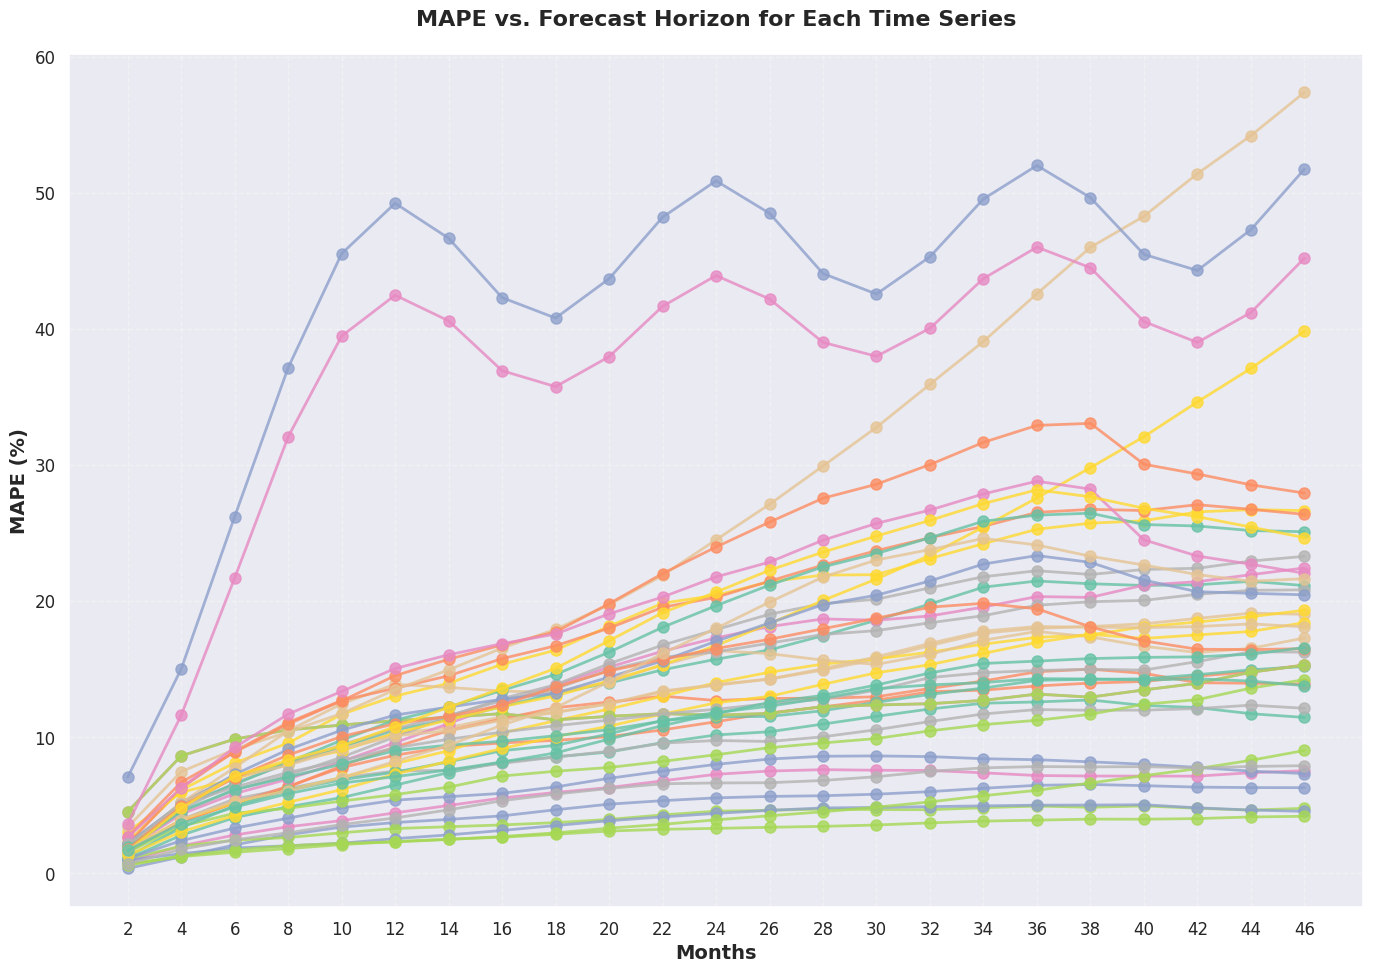

In [ ]:
plt.figure(figsize=(14, 10))

for col_idx in range(mape_matrix.shape[1]):
    plt.plot(
        np.arange(2, 48, 4),
        mape_matrix[:, col_idx],
        marker="o",
        markersize=8,
        linewidth=2,
        linestyle="-",
        alpha=0.8,
        label=f"Series {col_idx + 1}",
    )

plt.title(
    "MAPE vs. Forecast Horizon for Each Time Series",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Months", fontsize=14, fontweight="bold")
plt.ylabel("MAPE (%)", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.xticks(np.arange(2, 48, 4), fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

## Mix Model

Посмотрев на результаты экспериментов является очевидным смешать модели. В качестве базовой будет выступать последнее значение, на диагонали линейный экстраполятор, а помидоры и огурцы предсказывает сарима

In [79]:
%load_ext autoreload
%autoreload 2

from utils.models import MixModel, LinearExtrapolator

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [125]:
matrix_params = {
    "model_class": MixModel,
    "df": df,
    "horizon": 12,
    "stride": 4,
    "start_window": 60,
    "model_params": {},
}

In [ ]:
mix_model_matrices = {}

for horizon in tqdm(horizon_list):
    matrix_params["horizon"] = horizon
    mix_model_matrices[horizon] = build_short_error_matrix(**matrix_params)

In [82]:
matrix_params = {
    "model_class": LinearExtrapolator,
    "df": df,
    "horizon": 12,
    "stride": 4,
    "start_window": 60,
    "model_params": {},
}
le_model_matrices = {}

for horizon in tqdm(horizon_list):
    matrix_params["horizon"] = horizon
    le_model_matrices[f"{horizon}"] = build_error_matrix(**matrix_params)

100%|██████████| 4/4 [00:00<00:00, 13.68it/s]


### Посмотрим на получвшиеся матрицы ошибок

In [85]:
type(le_model_matrices["12"])

pandas.core.frame.DataFrame

In [98]:
# Create a copy of the result_matrix
sota =  {}

# Iterate through the diagonal elements
for horizon in horizon_list:
    sota[f"{horizon}"] = mix_model_matrices[horizon].copy()
    for i in range(len(sota[f"{horizon}"])):
        if i not in [34, 35]:  # Skip columns 34 and 35
            sota[f"{horizon}"].iloc[i, i] = le_model_matrices[f"{horizon}"].iloc[i, i]

  0%|          | 0/4 [00:00<?, ?it/s]

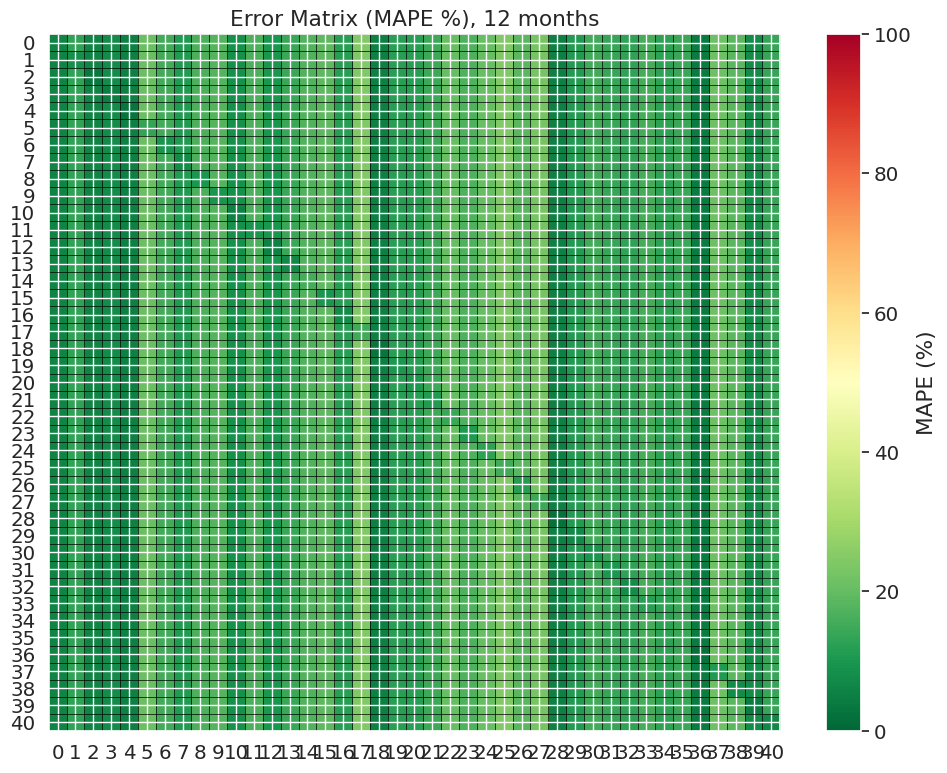

 25%|██▌       | 1/4 [00:00<00:01,  2.33it/s]

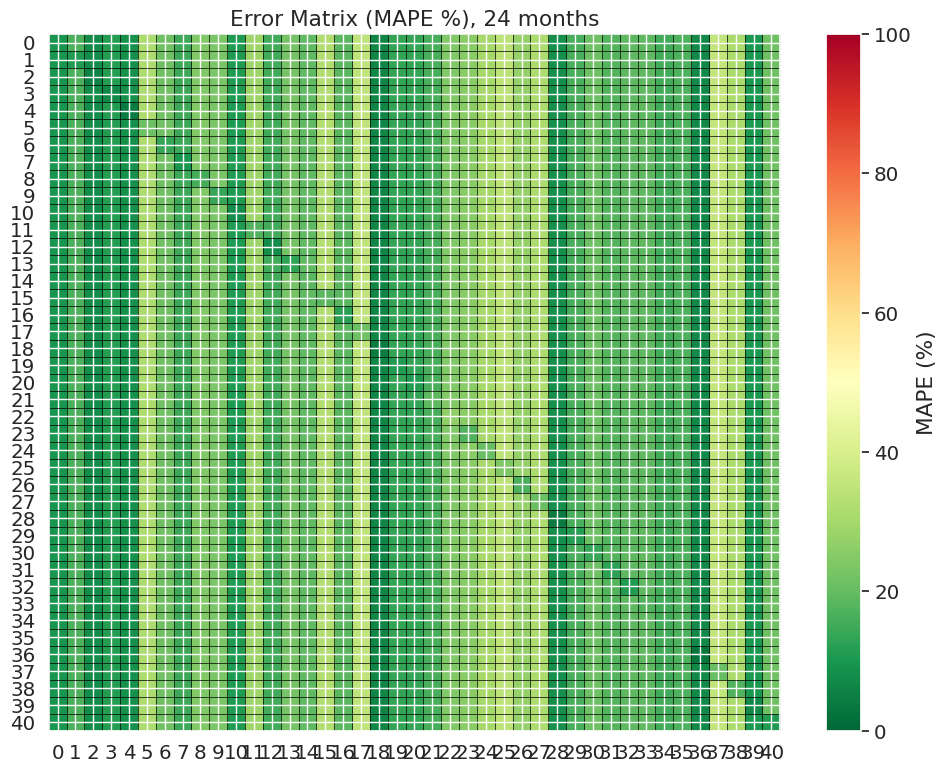

 50%|█████     | 2/4 [00:01<00:01,  1.48it/s]

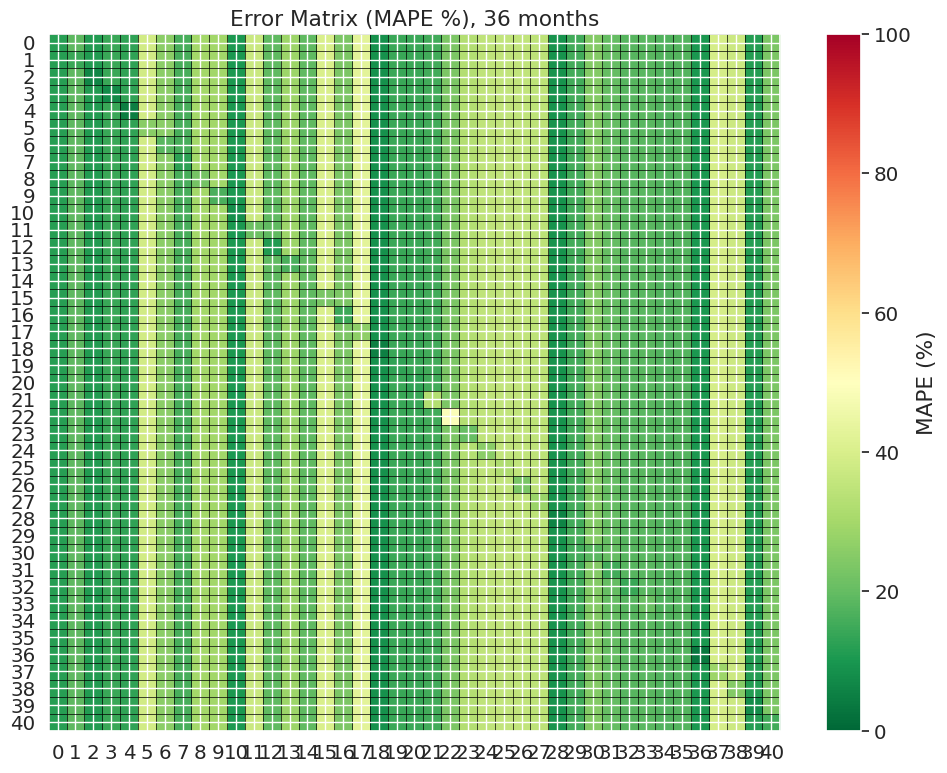

 75%|███████▌  | 3/4 [00:01<00:00,  1.76it/s]

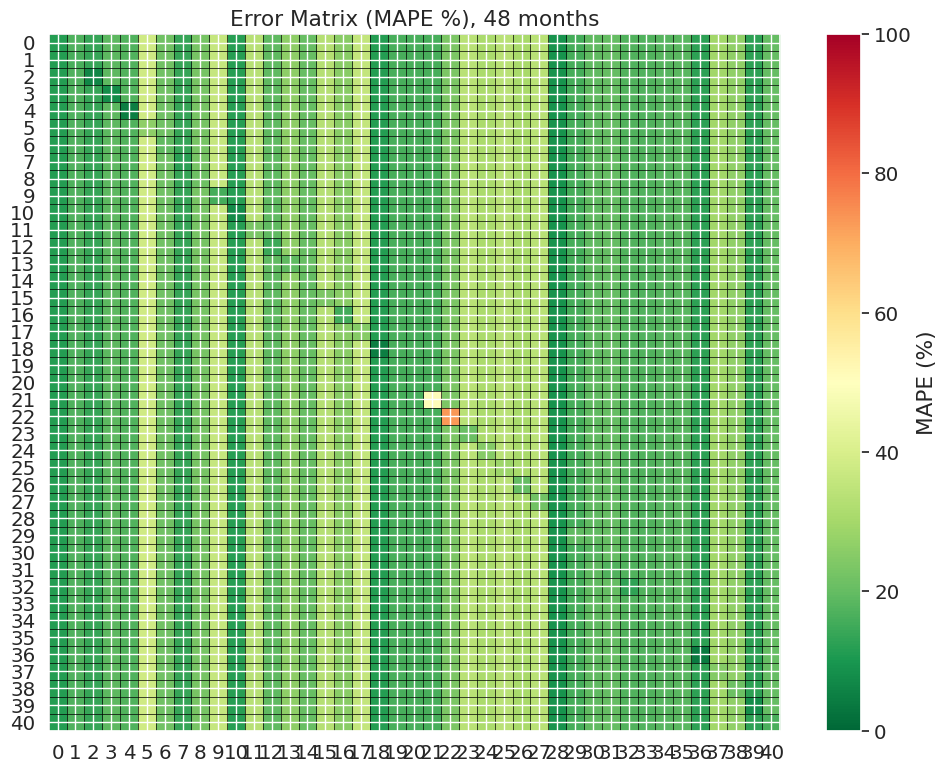

100%|██████████| 4/4 [00:02<00:00,  1.85it/s]


In [99]:
for horizon in tqdm(horizon_list):
    plot_error_matrix(sota[f"{horizon}"], title=f"Error Matrix (MAPE %), {horizon} months")

### Посмотрим на усреднённый по всем показателям MAPE

In [100]:
for horizon in horizon_list:
    print(f"{horizon} months:    ", end="")
    calc_average_error(mix_model_matrices[horizon])

12 months:    14.08%
24 months:    19.85%
36 months:    22.98%
48 months:    22.02%


### Посмотрим на разницу

In [101]:
%load_ext autoreload
%autoreload 2

from utils.vis import plot_delta_matrix_anchored

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


  0%|          | 0/4 [00:00<?, ?it/s]

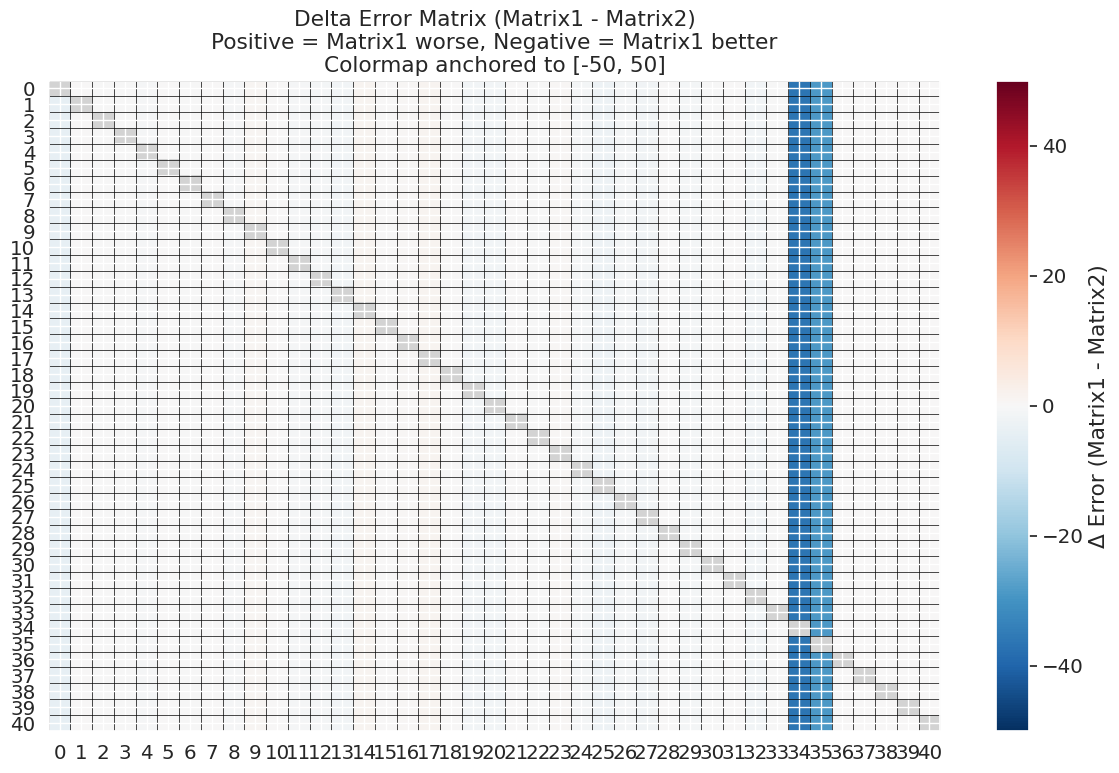

 25%|██▌       | 1/4 [00:00<00:01,  2.13it/s]

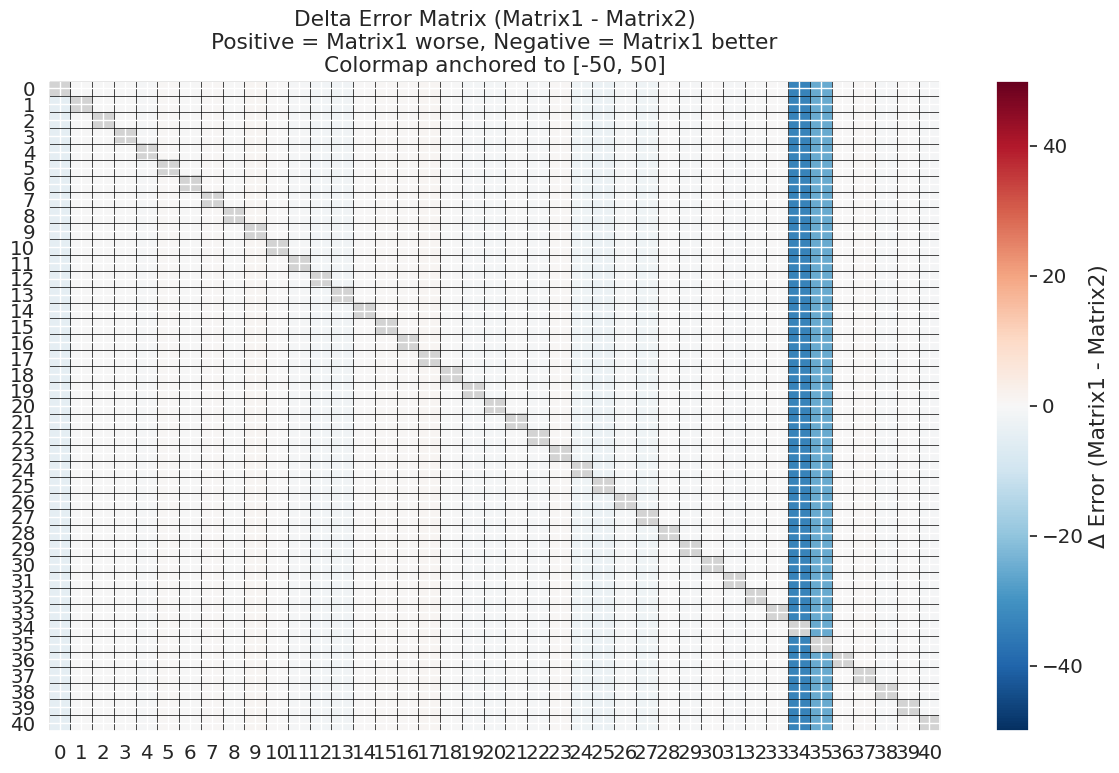

 50%|█████     | 2/4 [00:00<00:00,  2.17it/s]

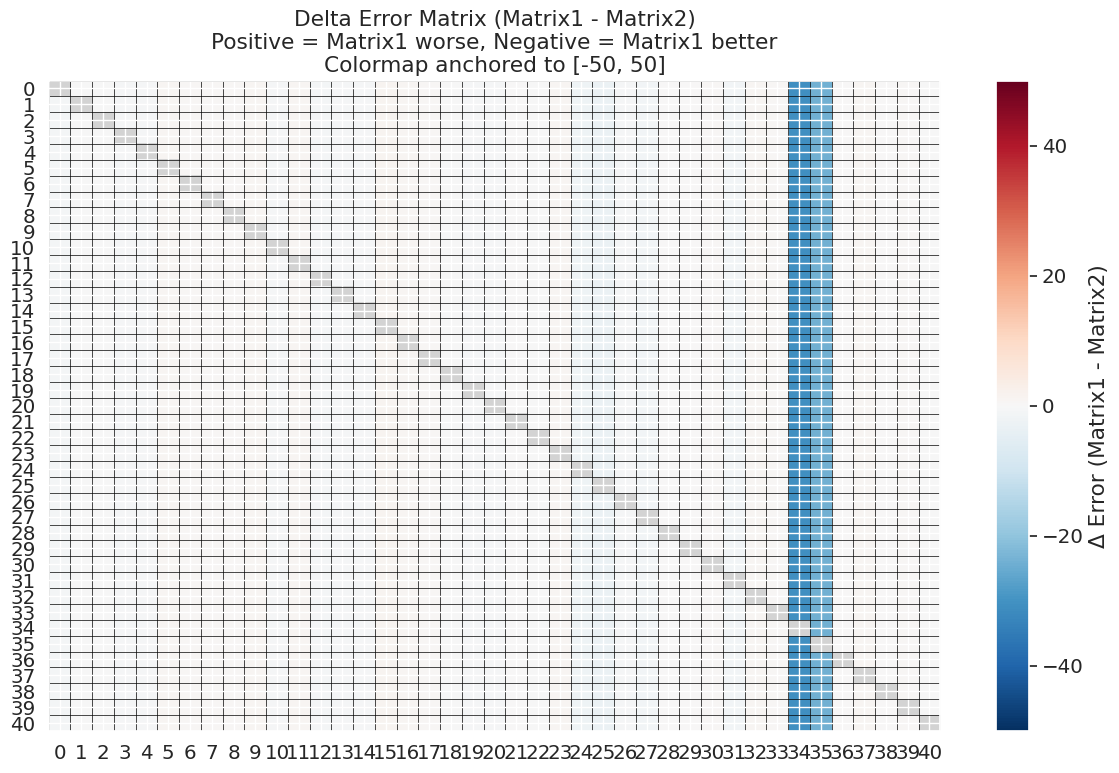

 75%|███████▌  | 3/4 [00:01<00:00,  1.74it/s]

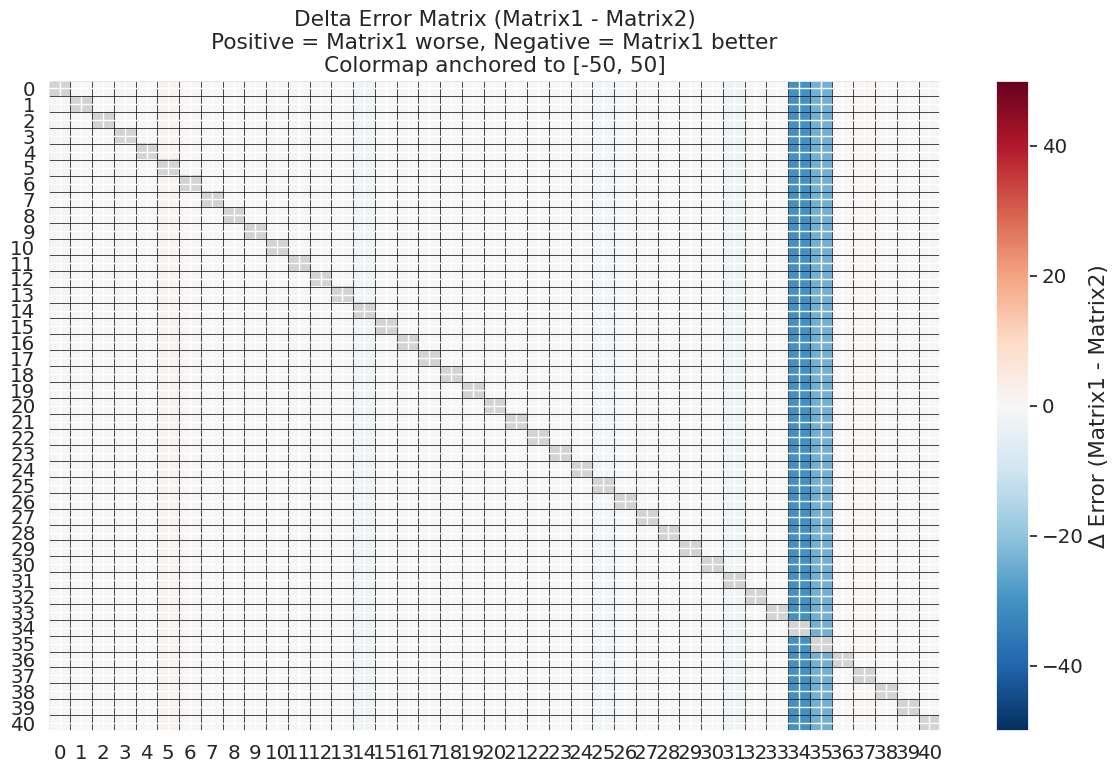

100%|██████████| 4/4 [00:02<00:00,  1.89it/s]


In [105]:
for horizon in tqdm(horizon_list):
    plot_delta_matrix_anchored(sota[f"{horizon}"], naive_model_matrices[horizon])

### Посмотрим на прогноз на помидорах и огурцах

In [106]:
%load_ext autoreload
%autoreload 2

from utils.models import SARIMAModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was ren

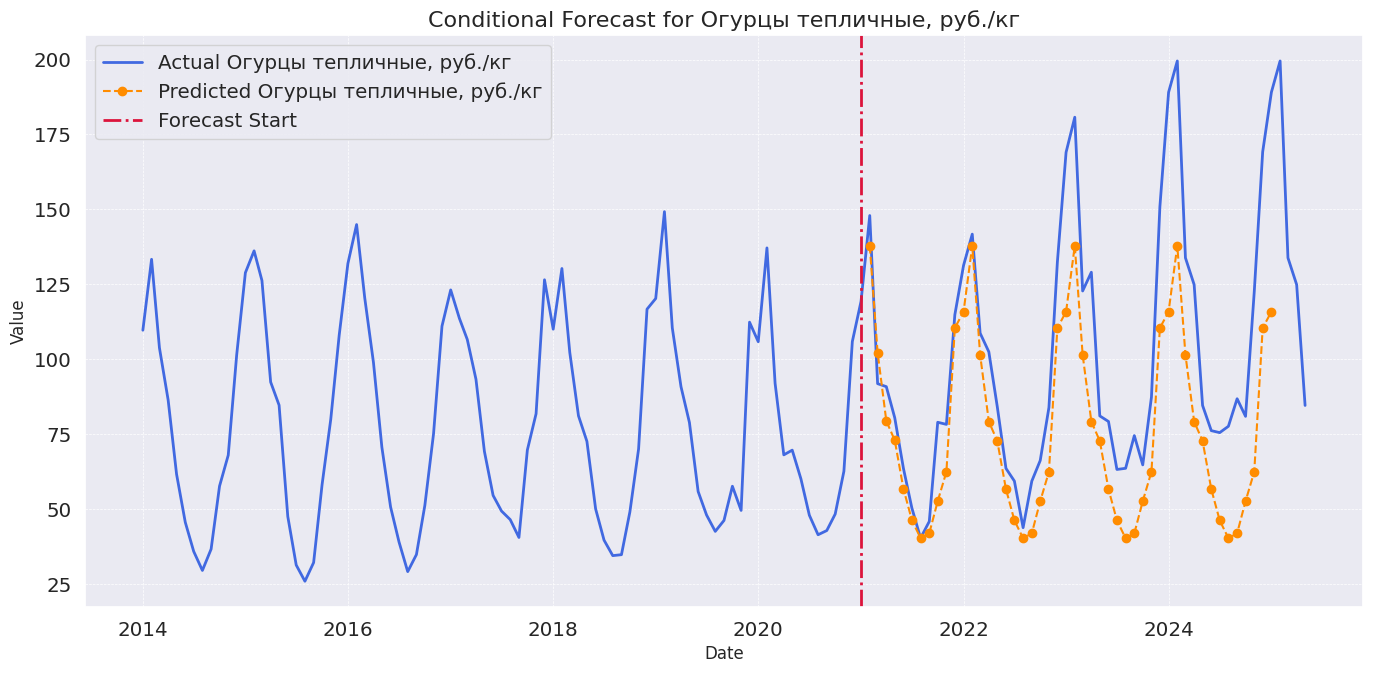

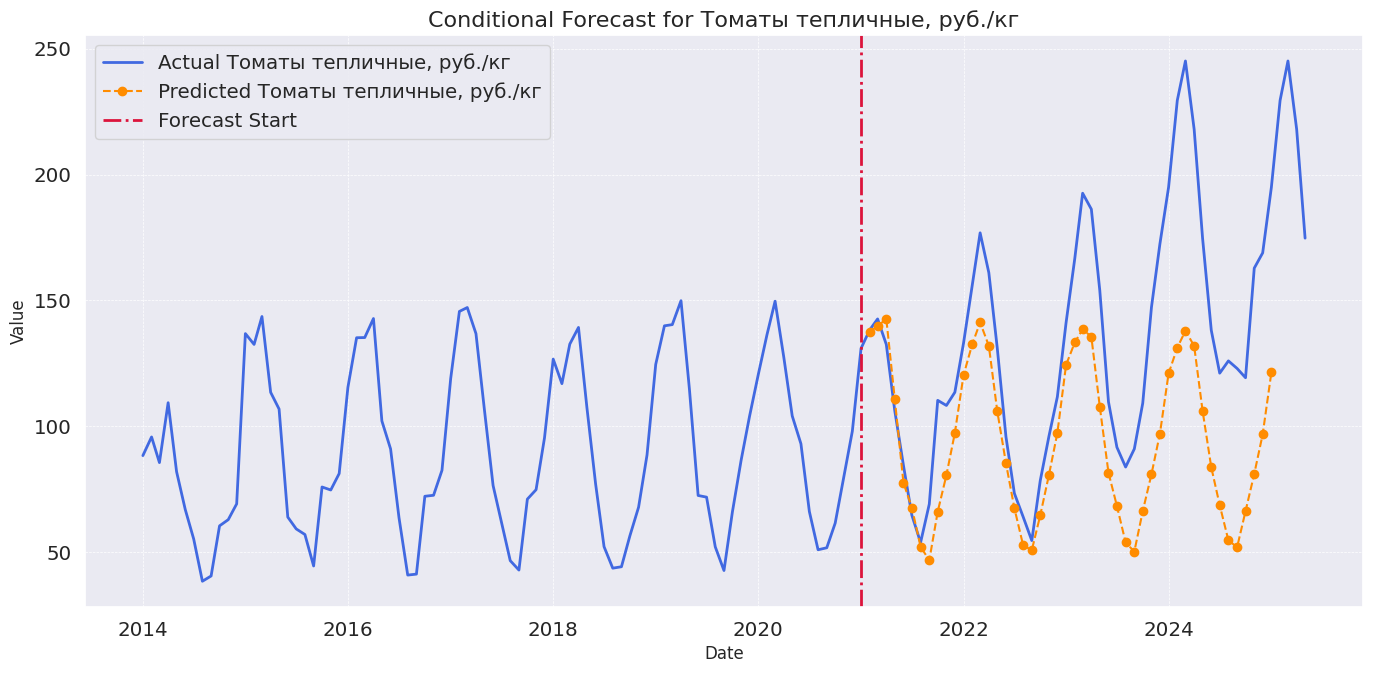

In [120]:
plot_model_pred(
    model_class=SARIMAModel,
    df=df[df.columns[34:36]],
    model_params={},
    conditioning_col=df.columns[35],
    horizon=48,
    cutoff_date="2021-01-01",
)

## DFM

In [2]:
from utils.models import DynamicFactorModel

In [8]:

horizon_list = [12]

In [9]:
matrix_params = {
    "model_class": DynamicFactorModel,
    "df": df,
    "horizon": 12,
    "stride": 24,
    "start_window": 60,
    "model_params": {"k_factors": 4, "factor_order": 4, "error_order": 2, "maxiter": 500},
}

In [12]:
dfm_model_matrices = {}

for horizon in tqdm(horizon_list):
    matrix_params["horizon"] = horizon
    dfm_model_matrices[horizon] = build_short_error_matrix(**matrix_params)

  0%|          | 0/1 [00:00<?, ?it/s]/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
  0%|          | 0/1 [17:52<?, ?it/s]


KeyboardInterrupt: 

### Посмотрим на получвшиеся матрицы ошибок

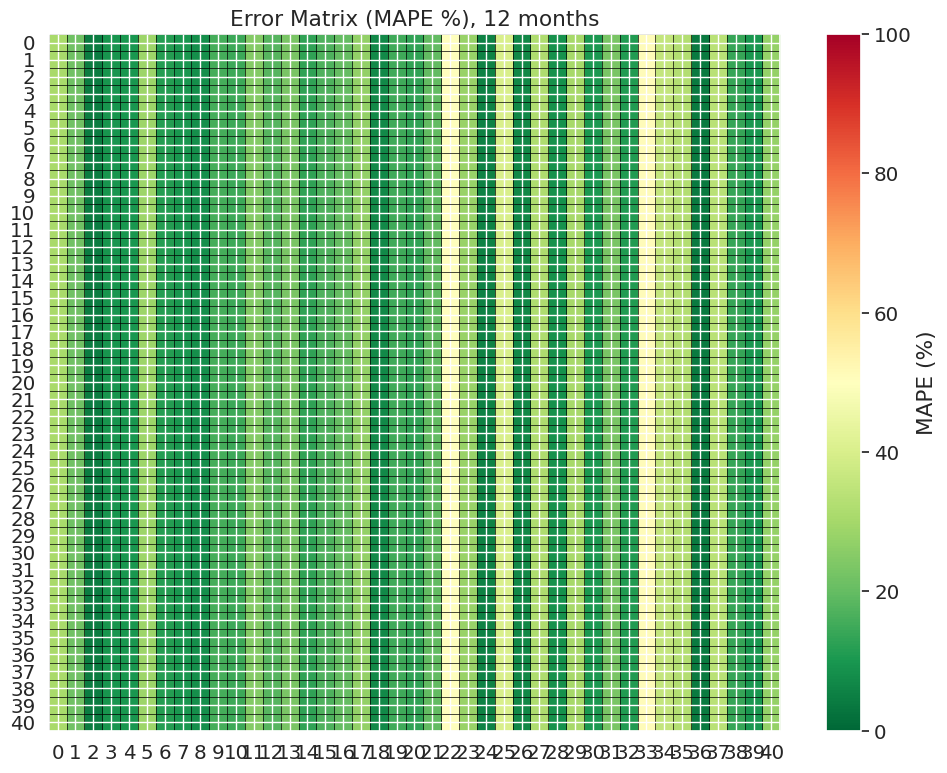

In [ ]:
for horizon in tqdm(horizon_list):
    plot_error_matrix(dfm_model_matrices[horizon], title=f"Error Matrix (MAPE %), {horizon} months")

### Ряды

/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/home/danilach/mipt-stats/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


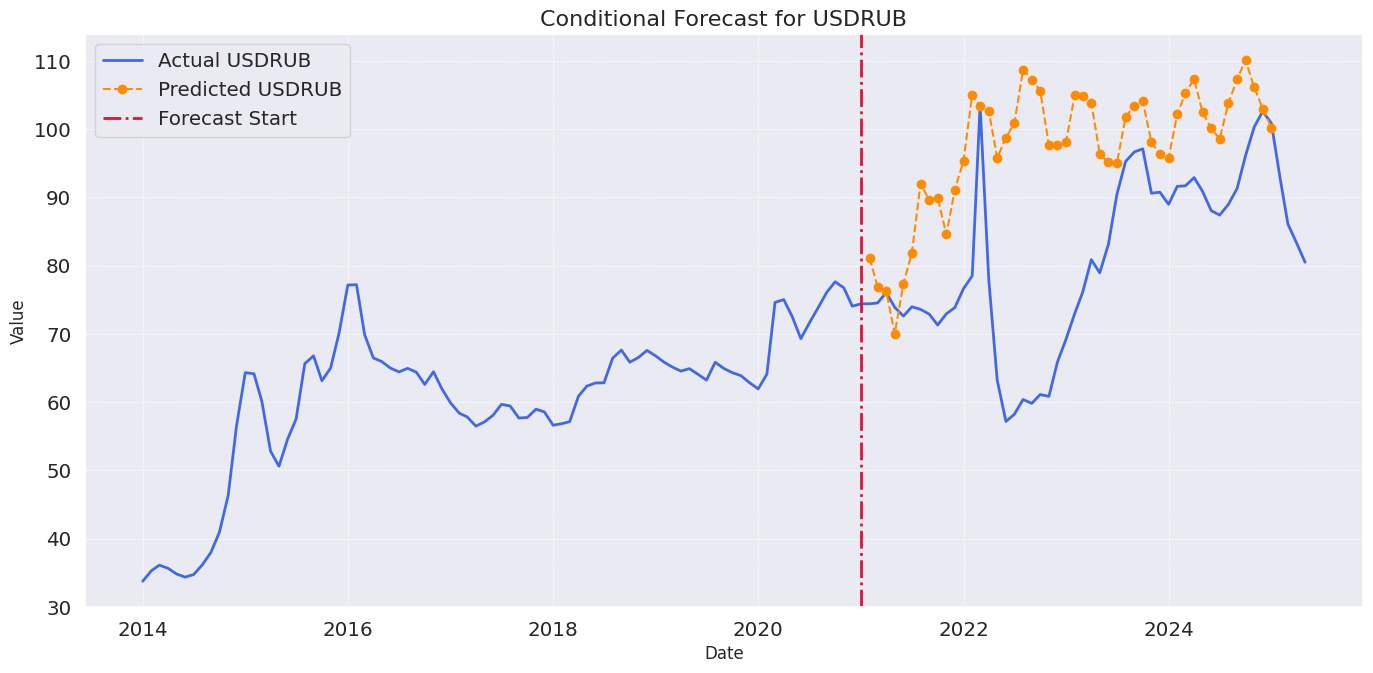

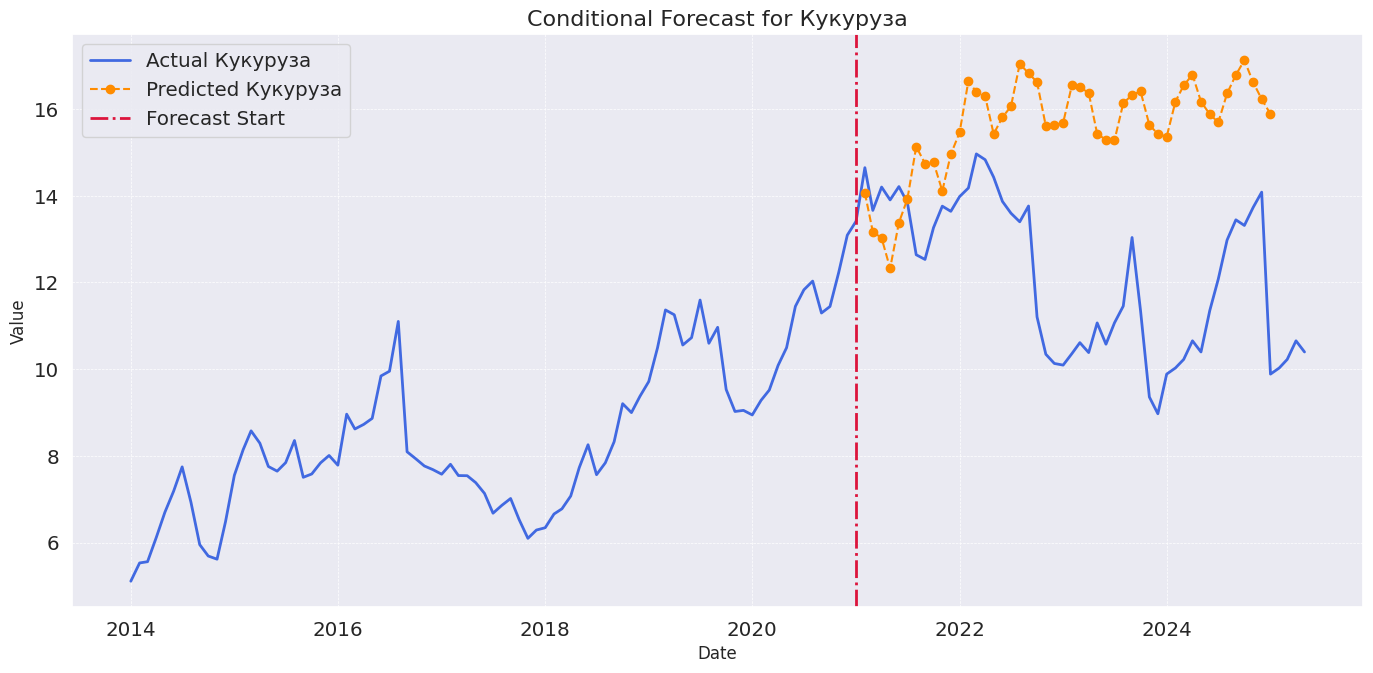

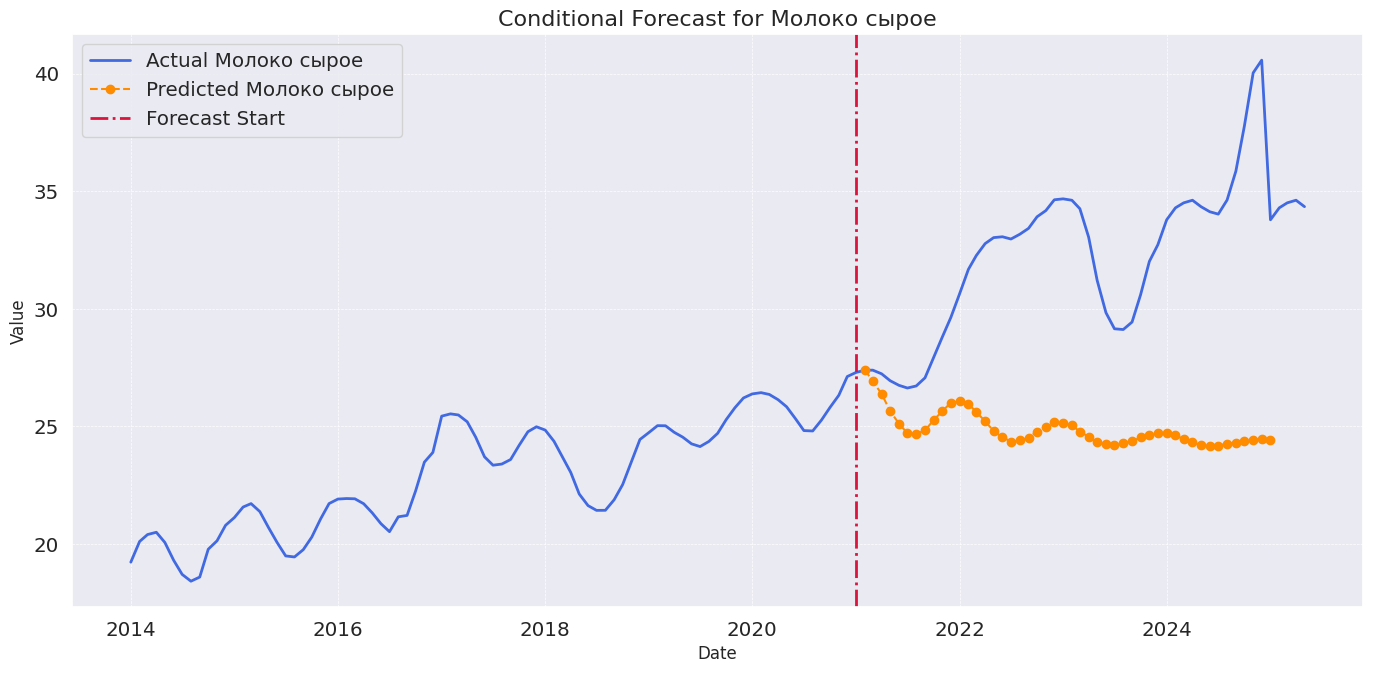

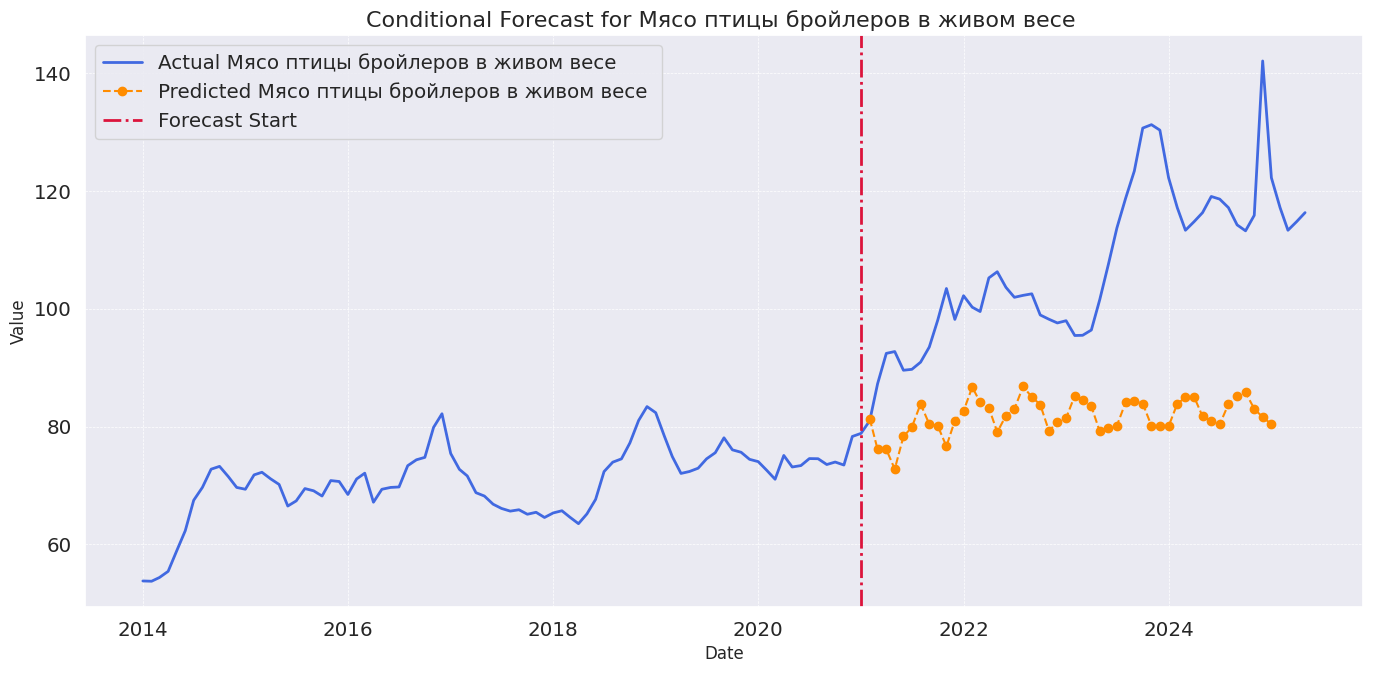

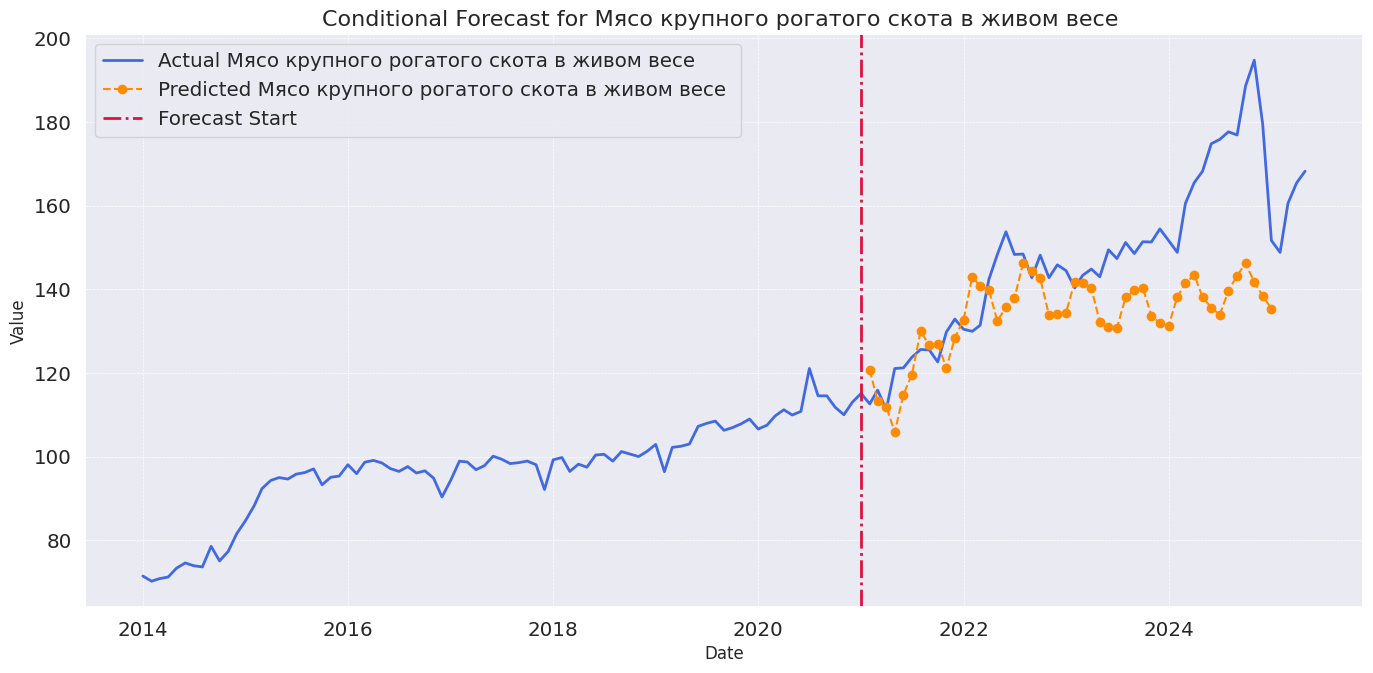

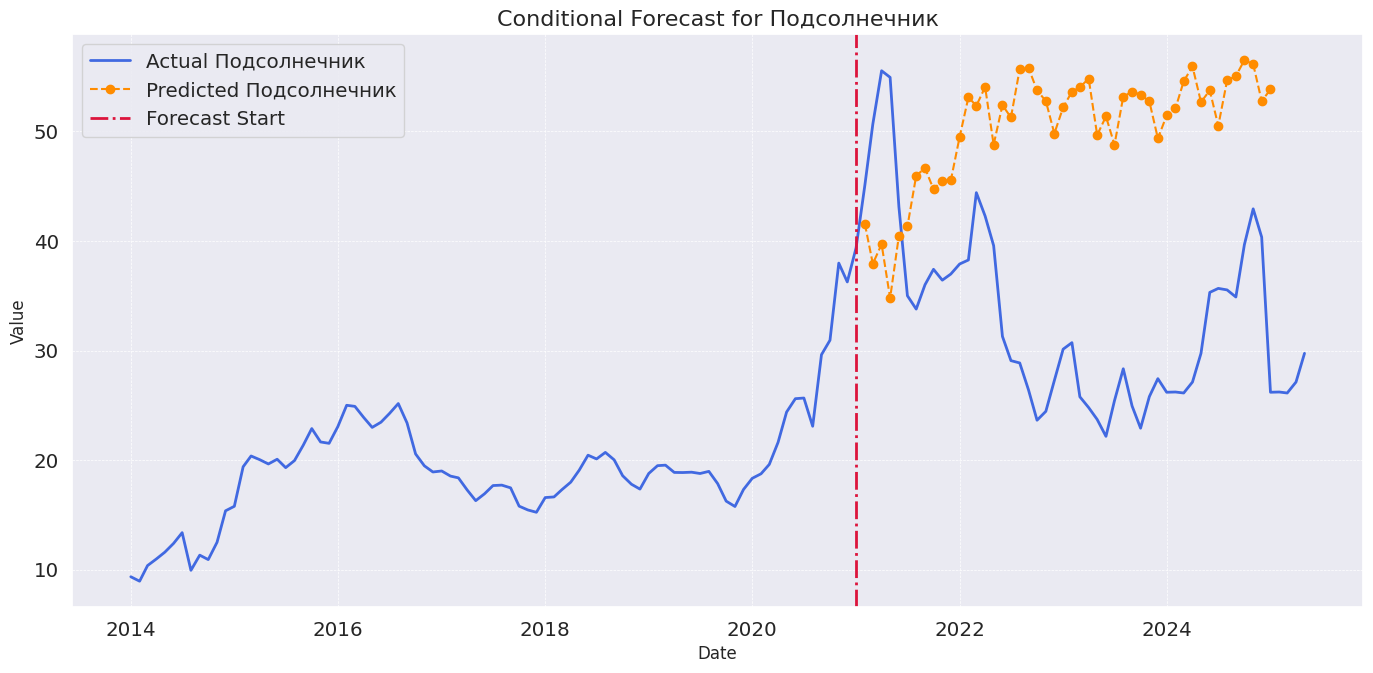

In [143]:
plot_model_pred(
    model_class=DynamicFactorModel,
    df=df[df.columns[:6]],
    model_params={"k_factors": 3, "factor_order": 4, "error_order": 3, "maxiter": 400},
    conditioning_col=df.columns[3],
    horizon=48,
    cutoff_date="2021-01-01",
)